# Cross-ply cylinders under a sinusoidal load: Varadan and Bhaskar (1991)

T. K. Varadan and K. Bhaskar, *Bending of laminated orthotropic cylindrical shells - an elasticity approach*, Composite Structures 17 (1991) 141-156.

Closed cross-ply cylinders of mean radius $R_0$, length $L = 4 R_0$ and shear-diaphragm ends, under the load $q = Q \sin(\pi x/L) \cos(4\theta)$ applied on the inner surface, pushing outwards, with the 3D elasticity solution as reference:

- material of Pagano: $E_L/E_T = 25$, $G_{LT}/E_T = 0.5$, $G_{TT}/E_T = 0.2$, $\nu_{LT} = \nu_{TT} = 0.25$, 0 deg along the axis, plies of equal thickness;
- lay-ups, from the outer surface: $90$, $90/0$, $90/0/90$ and $(90/0/90/0/90)_s$;
- $S = R_0/h$ = 2, 4, 10, 50, 100 and 500;
- reference: the radial displacement of the mid-surface ($\xi = 0$) of Tables 1-4, normalized as $\bar{U}_r = 10 E_L u_r/(Q h S^4)$, with $E_L$.

The data are those of `REFERENCE_DATA.md` of the paper study, copied in `scf_validation_utils.py`.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import scf_validation_utils as su
from scf_validation_utils import pct, markdown_table

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'

## panels model

The closed cylinder with $n = 4$ circumferential waves is represented exactly by a shear-diaphragm panel of angle $\pi/4$, $0 \le y \le \pi R_0/4$, loaded by $Q \sin(\pi x/L) \sin(4 y/R_0)$ (the $\cos 4\theta$ shifted by a quarter wave), with the shear-diaphragm condition `'D'` on the four edges (`bcs='DDDD'`): $w = 0$ and the tangential displacement and rotation zero, as in `tests/tests_shell/test_fsdt_tsdt_cylinders.py`. The models are the cylindrical shells with Sanders' kinematics, `cylshell_clpt_sanders`, `cylshell_fsdt_sanders` and `cylshell_tsdt_sanders`, with $14 \times 14$ terms; $w$ is positive outwards, the direction of the load. The stack of panels goes from the inner to the outer surface, e.g. `[0, 90]` for the lay-up $90/0$ with the 90 deg ply outside.

The FSDT is run with $\kappa = 5/6$ (`K56`), `'rohwer'` (`ROH`) and `'birman_bert'` (`BB`). The load acts on the inner surface, as in the 3D problem: `add_pressure_load(p, zp=-h/2)` applies the resultant $Q(1 - h/(2R_0))$ per unit mid-surface area. As a sensitivity case, the load is also applied on the mid-surface, `add_pressure_load(p)`, which increases all the displacements of the equivalent single-layer models by $1/(1 - h/(2R_0))$, 33% for $S = 2$ and 5% for $S = 10$.

In [2]:
PLY = (25e6, 1e6, 0.25, 0.5e6, 0.5e6, 0.2e6)  # Pagano, Eq. (38), psi
E_L = 25e6
N_WAVES = 4
L_R = 4.
# stacks from the inner to the outer surface, as required by panels
LAYUPS = {'90': [90], '90/0': [0, 90], '90/0/90': [90, 0, 90],
          '(90/0/90/0/90)s': [90, 0, 90, 0, 90, 90, 0, 90, 0, 90]}
SCFS = ['K56', 'ROH', 'BB']
M = 14
Q0 = 1.


def ubar(theory, scf, R, h, stack, zp=0.):
    r'''Normalized radial displacement of the mid-surface at the center of the panel'''
    L = L_R*R
    n = len(stack)
    s = su.make_shell(theory, L, np.pi*R/N_WAVES, stack, [h/n]*n, [PLY]*n, [1.]*n, r=R, scf=scf,
                      bcs='DDDD', m=M, n=M)
    s.add_pressure_load(lambda x, y: Q0*np.sin(np.pi*x/L)*np.sin(N_WAVES*y/R), zp=zp)
    c = su.static_linear(s)
    S = R/h
    return 10*E_L*su.center(s, c)/(Q0*h*S**4)


def compute():
    R = 1.
    res = {}
    for name, stack in LAYUPS.items():
        n = len(stack)
        for rh in su.VARADAN_R_H:
            h = R/rh
            out = {}
            for label, theory, scf in su.models(SCFS, stack, [h/n]*n, [PLY]*n, [1.]*n):
                out[label] = ubar(theory, scf, R, h, stack)
                out[label + ', zp = -h/2'] = ubar(theory, scf, R, h, stack, zp=-h/2)
            res['%s S%d' % (name, rh)] = out
    return res


res = su.run_or_load(os.path.join(RESULTS, 'varadan1991_cylinders.json'), compute, rerun=RERUN)
MODELS = ['CLPT'] + ['FSDT-' + k for k in SCFS] + ['TSDT']
# main case: load on the inner surface; sensitivity case: on the mid-surface
INNER = ', zp = -h/2'


def inner(r, m):
    return r[m + INNER]


def mid(r, m):
    return r[m]

## Tables 1-4: radial displacement

$\bar{U}_r$ at the mid-surface, load on the inner surface, with the difference to the 3D solution in parentheses.

In [3]:
for name in LAYUPS:
    rows = []
    for rh, ref in zip(su.VARADAN_R_H, su.VARADAN_1991[name]):
        r = res['%s S%d' % (name, rh)]
        rows.append([rh, ref] + ['%.4f (%+.1f%%)' % (inner(r, m), pct(inner(r, m), ref)) for m in MODELS])
    display(Markdown('**%s**' % name))
    display(Markdown(markdown_table(['$R_0/h$', '3D'] + MODELS, rows)))

**90**

| $R_0/h$ | 3D | CLPT | FSDT-K56 | FSDT-ROH | FSDT-BB | TSDT |
|---|---|---|---|---|---|---|
| 2 | 7.503 | 0.4058 (-94.6%) | 8.3254 (+11.0%) | 8.3254 (+11.0%) | 7.0092 (-6.6%) | 6.8067 (-9.3%) |
| 4 | 2.783 | 0.4661 (-83.3%) | 2.7841 (+0.0%) | 2.7841 (+0.0%) | 2.3985 (-13.8%) | 2.6539 (-4.6%) |
| 10 | 0.9189 | 0.5037 (-45.2%) | 0.9070 (-1.3%) | 0.9070 (-1.3%) | 0.8398 (-8.6%) | 0.9032 (-1.7%) |
| 50 | 0.5385 | 0.5208 (-3.3%) | 0.5374 (-0.2%) | 0.5374 (-0.2%) | 0.5346 (-0.7%) | 0.5374 (-0.2%) |
| 100 | 0.517 | 0.5123 (-0.9%) | 0.5163 (-0.1%) | 0.5163 (-0.1%) | 0.5156 (-0.3%) | 0.5163 (-0.1%) |
| 500 | 0.306 | 0.3057 (-0.1%) | 0.3058 (-0.1%) | 0.3058 (-0.1%) | 0.3057 (-0.1%) | 0.3058 (-0.1%) |

**90/0**

| $R_0/h$ | 3D | CLPT | FSDT-K56 | FSDT-ROH | FSDT-BB | TSDT |
|---|---|---|---|---|---|---|
| 2 | 14.034 | 2.6105 (-81.4%) | 13.7156 (-2.3%) | 13.8824 (-1.1%) | 10.8531 (-22.7%) | 10.8364 (-22.8%) |
| 4 | 6.1 | 2.7253 (-55.3%) | 5.9801 (-2.0%) | 6.0290 (-1.2%) | 5.1397 (-15.7%) | 5.3977 (-11.5%) |
| 10 | 3.33 | 2.7460 (-17.5%) | 3.3059 (-0.7%) | 3.3143 (-0.5%) | 3.1611 (-5.1%) | 3.2220 (-3.2%) |
| 50 | 2.242 | 2.2223 (-0.9%) | 2.2377 (-0.2%) | 2.2379 (-0.2%) | 2.2337 (-0.4%) | 2.2355 (-0.3%) |
| 100 | 1.367 | 1.3642 (-0.2%) | 1.3657 (-0.1%) | 1.3657 (-0.1%) | 1.3653 (-0.1%) | 1.3655 (-0.1%) |
| 500 | 0.1005 | 0.1005 (-0.0%) | 0.1005 (-0.0%) | 0.1005 (-0.0%) | 0.1005 (-0.0%) | 0.1005 (-0.0%) |

**90/0/90**

| $R_0/h$ | 3D | CLPT | FSDT-K56 | FSDT-ROH | FSDT-BB | TSDT |
|---|---|---|---|---|---|---|
| 2 | 10.11 | 0.4242 (-95.8%) | 10.2543 (+1.4%) | 14.3973 (+42.4%) | 11.4747 (+13.5%) | 9.4807 (-6.2%) |
| 4 | 4.009 | 0.4841 (-87.9%) | 3.3700 (-15.9%) | 4.5993 (+14.7%) | 3.7381 (-6.8%) | 3.7142 (-7.4%) |
| 10 | 1.223 | 0.5215 (-57.4%) | 1.0231 (-16.3%) | 1.2379 (+1.2%) | 1.0876 (-11.1%) | 1.1193 (-8.5%) |
| 50 | 0.5495 | 0.5212 (-5.2%) | 0.5405 (-1.6%) | 0.5487 (-0.1%) | 0.5429 (-1.2%) | 0.5444 (-0.9%) |
| 100 | 0.4715 | 0.4656 (-1.2%) | 0.4695 (-0.4%) | 0.4711 (-0.1%) | 0.4700 (-0.3%) | 0.4703 (-0.3%) |
| 500 | 0.1027 | 0.1027 (-0.0%) | 0.1027 (-0.0%) | 0.1027 (-0.0%) | 0.1027 (-0.0%) | 0.1027 (-0.0%) |

**(90/0/90/0/90)s**

| $R_0/h$ | 3D | CLPT | FSDT-K56 | FSDT-ROH | FSDT-BB | TSDT |
|---|---|---|---|---|---|---|
| 2 | 11.44 | 0.6119 (-94.7%) | 10.8919 (-4.8%) | 12.6457 (+10.5%) | 11.2727 (-1.5%) | 8.5996 (-24.8%) |
| 4 | 4.206 | 0.7018 (-83.3%) | 3.7231 (-11.5%) | 4.2338 (+0.7%) | 3.8363 (-8.8%) | 3.4002 (-19.2%) |
| 10 | 1.38 | 0.7567 (-45.2%) | 1.2815 (-7.1%) | 1.3702 (-0.7%) | 1.3013 (-5.7%) | 1.2460 (-9.7%) |
| 50 | 0.7622 | 0.7388 (-3.1%) | 0.7581 (-0.5%) | 0.7614 (-0.1%) | 0.7588 (-0.4%) | 0.7570 (-0.7%) |
| 100 | 0.6261 | 0.6217 (-0.7%) | 0.6251 (-0.2%) | 0.6257 (-0.1%) | 0.6252 (-0.1%) | 0.6249 (-0.2%) |
| 500 | 0.1006 | 0.1006 (-0.0%) | 0.1006 (-0.0%) | 0.1006 (-0.0%) | 0.1006 (-0.0%) | 0.1006 (-0.0%) |

In [4]:
for label, Ss in (('R0/h <= 10', [2, 4, 10]), ('R0/h >= 50', [50, 100, 500])):
    cols = {m: [pct(inner(res['%s S%d' % (name, rh)], m), ref) for name in LAYUPS
                for rh, ref in zip(su.VARADAN_R_H, su.VARADAN_1991[name]) if rh in Ss] for m in MODELS}
    display(Markdown('**All lay-ups, %s, load on the inner surface**' % label))
    display(Markdown(su.stats_table(cols)))
for name in LAYUPS:
    cols = {m: [pct(inner(res['%s S%d' % (name, rh)], m), ref)
                for rh, ref in zip(su.VARADAN_R_H, su.VARADAN_1991[name]) if rh <= 10] for m in MODELS}
    display(Markdown('**%s, $R_0/h \\le 10$**' % name))
    display(Markdown(su.stats_table(cols)))

**All lay-ups, R0/h <= 10, load on the inner surface**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 95.8 | 70.1 | -95.8 to -17.5 |
| FSDT-K56 | 16.3 | 6.2 | -16.3 to +11.0 |
| FSDT-ROH | 42.4 | 7.1 | -1.3 to +42.4 |
| FSDT-BB | 22.7 | 10.0 | -22.7 to +13.5 |
| TSDT | 24.8 | 10.7 | -24.8 to -1.7 |

**All lay-ups, R0/h >= 50, load on the inner surface**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 5.2 | 1.3 | -5.2 to -0.0 |
| FSDT-K56 | 1.6 | 0.3 | -1.6 to -0.0 |
| FSDT-ROH | 0.2 | 0.1 | -0.2 to -0.0 |
| FSDT-BB | 1.2 | 0.3 | -1.2 to -0.0 |
| TSDT | 0.9 | 0.2 | -0.9 to -0.0 |

**90, $R_0/h \le 10$**

...

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 81.4 | 51.4 | -81.4 to -17.5 |
| FSDT-K56 | 2.3 | 1.7 | -2.3 to -0.7 |
| FSDT-ROH | 1.2 | 0.9 | -1.2 to -0.5 |
| FSDT-BB | 22.7 | 14.5 | -22.7 to -5.1 |
| TSDT | 22.8 | 12.5 | -22.8 to -3.2 |

**90/0/90, $R_0/h \le 10$**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 95.8 | 80.4 | -95.8 to -57.4 |
| FSDT-K56 | 16.3 | 11.2 | -16.3 to +1.4 |
| FSDT-ROH | 42.4 | 19.4 | +1.2 to +42.4 |
| FSDT-BB | 13.5 | 10.4 | -11.1 to +13.5 |
| TSDT | 8.5 | 7.4 | -8.5 to -6.2 |

**(90/0/90/0/90)s, $R_0/h \le 10$**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 94.7 | 74.4 | -94.7 to -45.2 |
| FSDT-K56 | 11.5 | 7.8 | -11.5 to -4.8 |
| FSDT-ROH | 10.5 | 4.0 | -0.7 to +10.5 |
| FSDT-BB | 8.8 | 5.3 | -8.8 to -1.5 |
| TSDT | 24.8 | 17.9 | -24.8 to -9.7 |

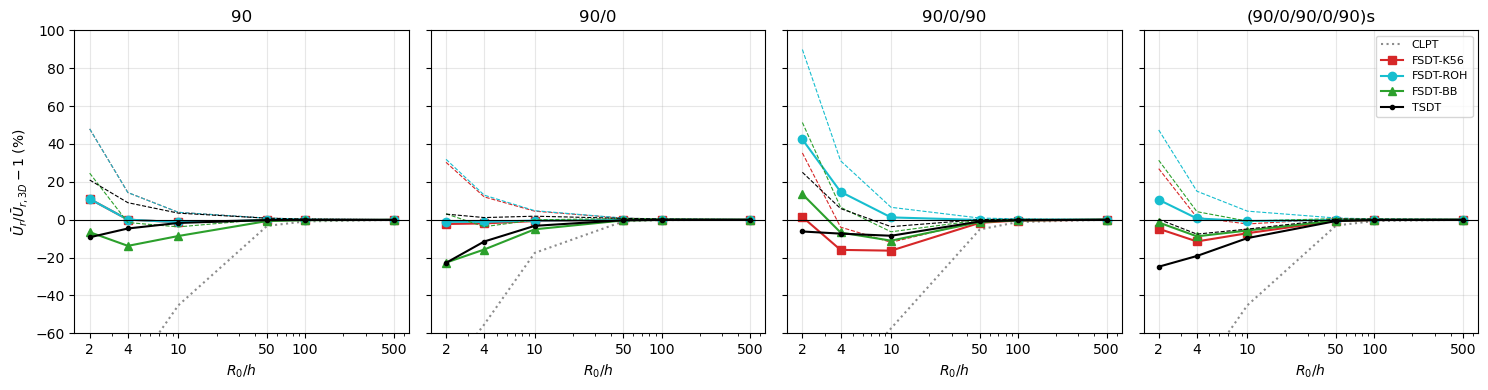

In [5]:
styles = {'CLPT': dict(color='0.55', ls=':'), 'FSDT-K56': dict(color='tab:red', marker='s'),
          'FSDT-ROH': dict(color='tab:cyan', marker='o'), 'FSDT-BB': dict(color='tab:green', marker='^'),
          'TSDT': dict(color='k', marker='.')}
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
for ax, name in zip(axes, LAYUPS):
    refs = su.VARADAN_1991[name]
    for m in MODELS:
        ax.plot(su.VARADAN_R_H, [pct(inner(res['%s S%d' % (name, rh)], m), ref)
                                 for rh, ref in zip(su.VARADAN_R_H, refs)], label=m, **styles[m])
        if m != 'CLPT':
            ax.plot(su.VARADAN_R_H, [pct(mid(res['%s S%d' % (name, rh)], m), ref)
                                     for rh, ref in zip(su.VARADAN_R_H, refs)], color=styles[m]['color'], ls='--', lw=0.8)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xscale('log')
    ax.set_xticks(su.VARADAN_R_H)
    ax.set_xticklabels(su.VARADAN_R_H)
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_ylim(-60, 100)
    ax.set_xlabel('$R_0/h$')
    ax.set_title(name)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('$\\bar{U}_r/\\bar{U}_{r, 3D} - 1$ (%)')
axes[-1].legend(fontsize=8)
plt.tight_layout()

Full lines: load on the inner surface; thin dashed lines: load on the mid-surface. The CLPT, $-81\%$ to $-96\%$ for $R_0/h = 2$, is cut by the vertical limits.

### Sensitivity: load on the mid-surface

The same comparison with the load $Q$ applied on the mid-surface, which increases all the displacements of the equivalent single-layer models by $1/(1 - h/(2R_0))$; only the thick cylinders are affected.

In [6]:
for name in LAYUPS:
    rows = []
    for rh, ref in zip(su.VARADAN_R_H[:3], su.VARADAN_1991[name][:3]):
        r = res['%s S%d' % (name, rh)]
        rows.append([rh, ref] + ['%.4f (%+.1f%%)' % (mid(r, m), pct(mid(r, m), ref))
                                 for m in MODELS])
    display(Markdown('**%s, load on the mid-surface**' % name))
    display(Markdown(markdown_table(['$R_0/h$', '3D'] + MODELS, rows)))
cols = {m: [pct(mid(res['%s S%d' % (name, rh)], m), ref) for name in LAYUPS
            for rh, ref in zip(su.VARADAN_R_H, su.VARADAN_1991[name]) if rh <= 10] for m in MODELS}
display(Markdown('**All lay-ups, $R_0/h \\le 10$, load on the mid-surface**'))
display(Markdown(su.stats_table(cols)))

**90, load on the mid-surface**

| $R_0/h$ | 3D | CLPT | FSDT-K56 | FSDT-ROH | FSDT-BB | TSDT |
|---|---|---|---|---|---|---|
| 2 | 7.503 | 0.5410 (-92.8%) | 11.1005 (+47.9%) | 11.1005 (+47.9%) | 9.3456 (+24.6%) | 9.0756 (+21.0%) |
| 4 | 2.783 | 0.5327 (-80.9%) | 3.1819 (+14.3%) | 3.1819 (+14.3%) | 2.7412 (-1.5%) | 3.0330 (+9.0%) |
| 10 | 0.9189 | 0.5302 (-42.3%) | 0.9547 (+3.9%) | 0.9547 (+3.9%) | 0.8840 (-3.8%) | 0.9507 (+3.5%) |

**90/0, load on the mid-surface**

| $R_0/h$ | 3D | CLPT | FSDT-K56 | FSDT-ROH | FSDT-BB | TSDT |
|---|---|---|---|---|---|---|
| 2 | 14.034 | 3.4807 (-75.2%) | 18.2875 (+30.3%) | 18.5099 (+31.9%) | 14.4707 (+3.1%) | 14.4485 (+3.0%) |
| 4 | 6.1 | 3.1147 (-48.9%) | 6.8344 (+12.0%) | 6.8903 (+13.0%) | 5.8740 (-3.7%) | 6.1688 (+1.1%) |
| 10 | 3.33 | 2.8905 (-13.2%) | 3.4799 (+4.5%) | 3.4887 (+4.8%) | 3.3275 (-0.1%) | 3.3916 (+1.9%) |

**90/0/90, load on the mid-surface**

| $R_0/h$ | 3D | CLPT | FSDT-K56 | FSDT-ROH | FSDT-BB | TSDT |
|---|---|---|---|---|---|---|
| 2 | 10.11 | 0.5655 (-94.4%) | 13.6724 (+35.2%) | 19.1964 (+89.9%) | 15.2996 (+51.3%) | 12.6409 (+25.0%) |
| 4 | 4.009 | 0.5532 (-86.2%) | 3.8515 (-3.9%) | 5.2563 (+31.1%) | 4.2721 (+6.6%) | 4.2448 (+5.9%) |
| 10 | 1.223 | 0.5490 (-55.1%) | 1.0769 (-11.9%) | 1.3030 (+6.5%) | 1.1448 (-6.4%) | 1.1782 (-3.7%) |

**(90/0/90/0/90)s, load on the mid-surface**

| $R_0/h$ | 3D | CLPT | FSDT-K56 | FSDT-ROH | FSDT-BB | TSDT |
|---|---|---|---|---|---|---|
| 2 | 11.44 | 0.8158 (-92.9%) | 14.5226 (+26.9%) | 16.8609 (+47.4%) | 15.0302 (+31.4%) | 11.4661 (+0.2%) |
| 4 | 4.206 | 0.8021 (-80.9%) | 4.2550 (+1.2%) | 4.8386 (+15.0%) | 4.3843 (+4.2%) | 3.8859 (-7.6%) |
| 10 | 1.38 | 0.7965 (-42.3%) | 1.3489 (-2.3%) | 1.4423 (+4.5%) | 1.3698 (-0.7%) | 1.3115 (-5.0%) |

**All lay-ups, $R_0/h \le 10$, load on the mid-surface**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 94.4 | 67.1 | -94.4 to -13.2 |
| FSDT-K56 | 47.9 | 16.2 | -11.9 to +47.9 |
| FSDT-ROH | 89.9 | 25.9 | +3.9 to +89.9 |
| FSDT-BB | 51.3 | 11.5 | -6.4 to +51.3 |
| TSDT | 25.0 | 7.2 | -7.6 to +25.0 |

## Discussion

- **Thin cylinders.** For $R_0/h \ge 50$ all the shear deformable models are within 1.6% of the 3D radial displacement for the four lay-ups, the static correction `'rohwer'` within 0.2%, and the CLPT within 5.2% (the $90/0/90$ cylinder at $R_0/h = 50$). The equivalent single-layer models and the shear-diaphragm panel of one half-wave, $\pi R_0/4$, therefore reproduce the 3D solution in the thin limit.
- **Moderately thick cylinders, $R_0/h = 10$.** `'rohwer'` is within $-1.3\%$, $-0.5\%$, $+1.2\%$ and $-0.7\%$ of 3D for the lay-ups $90$, $90/0$, $90/0/90$ and $(90/0/90/0/90)_s$, $\kappa = 5/6$ is $-1.3\%$, $-0.7\%$, $-16.3\%$ and $-7.1\%$, `'birman_bert'` $-8.6\%$, $-5.1\%$, $-11.1\%$ and $-5.7\%$, and the TSDT $-1.7\%$, $-3.2\%$, $-8.5\%$ and $-9.7\%$. The ranking of the plates of Pagano holds: the static correction is the most accurate, and the TSDT is too stiff. For the single layer, `'rohwer'` and $5/6$ coincide.
- **Thick cylinders, $R_0/h \le 4$.** `'rohwer'` remains within 1.2% for $R_0/h = 4$ and three of the lay-ups, but overestimates the displacement of the $90/0/90$ cylinder by 15% ($R_0/h = 4$) and 42% ($R_0/h = 2$), where the curvature makes the factors of the flat laminate too flexible; over all cylinders with $R_0/h \le 10$ its mean difference is 7.1%, against 6.2% for $\kappa = 5/6$, 10.0% for `'birman_bert'`, 10.7% for the TSDT (which underestimates all the displacements, by up to 25%) and 70% for the CLPT.
- **Position of the load.** With the load on the mid-surface, all the displacements of the equivalent single-layer models increase by $1/(1 - h/(2R_0))$, 5% for $R_0/h = 10$ and 33% for $R_0/h = 2$: `'rohwer'` would then be $+3.9\%$ to $+6.5\%$ above 3D at $R_0/h = 10$ and up to $+90\%$ at $R_0/h = 2$, an apparent loss of accuracy of the static correction that is only due to the load resultant. The resultant of the 3D load must therefore be reproduced before comparing shear corrections on thick cylinders.